# Fine-Tuning an AI Scoring Model for the Smart ADHD Training System

This notebook fine-tunes a model on data produced by our four training games
(**Sequence Memory, Reaction Time, Red Light/Green Light, Mirror Me**) to power
the **AI Agent** described in Section 8 of the project documentation: it turns
raw per-trial gameplay signals into the three normalized scores
(**Attention, Impulsivity, Motor Control**, 0-100) plus next-session
recommendations.

## Why this model?

Peer-reviewed ADHD research (Continuous Performance Test / reaction-time
studies) consistently finds that **interpretable machine-learning models
trained on reaction-time and attention features** (reaction-time variability,
omission/commission-style errors, response consistency) are highly effective
at scoring attention and impulse-control from behavioral task data
(AUC ≈ 0.80-0.91 across multiple 2025 studies using Random Forest, SVM, and
Logistic Regression on CPT-style features). This matches our data almost
exactly: our `TrialData` table already captures the equivalent signals
(`ReactionTimeMs`, `AttentionPercent`, `PoseSimilarity`, `FreezeQuality`,
`FalseStart`).

Because a real graduation-project dataset is **small** (a few hundred to a
few thousand trials, not millions), we use **TabPFN v2**, a pretrained
*tabular foundation model* (transformer pretrained on millions of synthetic
tabular tasks, published in *Nature*, 2025) that is specifically built to be
fine-tuned on small/medium tabular datasets and beats classic gradient-boosted
trees in this regime with far less tuning effort. We fine-tune it directly on
our own trial-level game data, and compare it against an **XGBoost** baseline
(the standard, well-validated choice in the ADHD-ML literature) so you can
see the fine-tuning actually helps.

**What you get from this notebook:**
1. A data schema that mirrors our `TrialData` / `SessionAnalysis` tables exactly.
2. A synthetic dataset generator (swap this for your real exported CSV — see Section 1).
3. Fine-tuning of TabPFN v2 on our own game data for the 3 AI-Agent scores.
4. An XGBoost baseline for comparison.
5. A rule-based recommendation layer (Section 8.3 of the doc) built on top of the predicted scores.
6. Saving the fine-tuned model so it can be called from the .NET backend (via a small Python inference service) or exported.


## 0. Setup

Run this once. `tabpfn` needs a GPU for speed but also works on CPU for
small graduation-project-sized datasets.

In [64]:
# !pip install tabpfn


In [65]:
# !pip install -q tabpfn scikit-learn xgboost pandas numpy matplotlib pyodbc --no-cache-dir --break-system-packages


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.


## 1. Load real game data from SQL Server

This notebook reads directly from the ASP.NET Core / EF Core database and follows the latest backend and Games payloads.

It loads `DefaultConnection` from `D:/My_Projects/ADHD_2/back-end/ADHD.API/appsettings.json`, queries the concrete game tables, and joins persisted Hugging Face outputs from `ai_analyses` when they exist.

Current source tables: `game_sessions`, `session_summaries`, `mirror_me_trials`, `green_light_trials`, `simon_trials`, `reaction_trials`, and `ai_analyses`.

The loader normalizes fraction-style game metrics (`0.0-1.0`) to the notebook's `0-100` score scale, keeps trial-level rows for model training, and carries Hugging Face scores so Section 6.3 can compare notebook predictions against `HuggingFaceAnalysisService`.


In [67]:
import json
import os
from pathlib import Path

APPSETTINGS_PATH = Path(r"D:\My_Projects\ADHD_2\back-end\ADHD.API\appsettings.json")
SQL_DRIVER = os.getenv("ADHD_SQL_DRIVER", "ODBC Driver 17 for SQL Server")

SIMON_COLS = ["simon_level", "simon_sequence_length", "simon_speed", "simon_step", "simon_expected", "simon_pressed"]
REACTION_COLS = ["reaction_trial", "reaction_target_led", "reaction_delay", "reaction_result", "reaction_pressed_button", "reaction_impulsive_error"]
TARGET_COLS = ["attention_score", "impulsivity_score", "motor_control_score"]
HF_SCORE_COLS = ["hf_attention_score", "hf_impulsivity_score", "hf_motor_control_score"]


def ef_connection_to_odbc(connection_string: str, driver: str = SQL_DRIVER) -> str:
    parts = {}
    for item in connection_string.strip().strip(";").split(";"):
        if not item or "=" not in item:
            continue
        key, value = item.split("=", 1)
        parts[key.strip().lower()] = value.strip()
    server = parts.get("server") or parts.get("data source")
    database = parts.get("database") or parts.get("initial catalog")
    trusted = parts.get("trusted_connection", parts.get("integrated security", "false")).lower() in {"true", "sspi", "yes"}
    trust_cert_raw = parts.get("trustservercertificate", "yes").lower()
    trust_cert = "yes" if trust_cert_raw in {"true", "yes", "1"} else "no"
    if not server or not database:
        raise ValueError("DefaultConnection must include Server and Database.")
    odbc_parts = [f"DRIVER={{{driver}}}", f"SERVER={server}", f"DATABASE={database}", f"TrustServerCertificate={trust_cert}"]
    if trusted:
        odbc_parts.append("Trusted_Connection=yes")
    else:
        user = parts.get("user id") or parts.get("uid")
        password = parts.get("password") or parts.get("pwd")
        if not user or not password:
            raise ValueError("SQL authentication requires User Id and Password in DefaultConnection.")
        odbc_parts.extend([f"UID={user}", f"PWD={password}"])
    return ";".join(odbc_parts) + ";"


def load_default_connection(appsettings_path: Path = APPSETTINGS_PATH) -> str:
    override = os.getenv("ADHD_DB_CONNECTION_STRING")
    if override:
        return override
    settings = json.loads(appsettings_path.read_text(encoding="utf-8"))
    return settings["ConnectionStrings"]["DefaultConnection"]


def add_game_specific_defaults(df):
    for col in SIMON_COLS + REACTION_COLS + HF_SCORE_COLS:
        if col not in df.columns:
            df[col] = np.nan
    df["reaction_impulsive_error"] = df["reaction_impulsive_error"].fillna(0).astype(int)
    return df


def load_game_data_from_database():
    import pyodbc
    odbc_connection = ef_connection_to_odbc(load_default_connection())
    query = r'''
    WITH session_base AS (
        SELECT
            s.Id AS session_id,
            s.ChildId AS child_id,
            s.GameType AS game_type,
            COALESCE(s.SessionNumber, 1) AS session_number,
            (
                SELECT COUNT(1)
                FROM game_sessions prev
                WHERE prev.ChildId = s.ChildId
                  AND prev.Id <> s.Id
                  AND (COALESCE(prev.CreatedAt, '1900-01-01') < COALESCE(s.CreatedAt, '1900-01-01') OR prev.Id < s.Id)
            ) AS prev_sessions_count,
            ss.TotalTrials, ss.AverageReactionTimeMs, ss.AverageSimilarity, ss.TotalFidgetScore,
            ss.AttentionOverall, ss.AverageStopReactionTimeMs, ss.FalseStartCount, ss.AverageFreezeQuality,
            ss.MovementIntensityOverall, ss.FinalLevel, ss.TotalCorrectSteps, ss.TotalSteps,
            ss.PrematurePressesDuringShow, ss.EndStatus, ss.Hits, ss.FalseStarts, ss.Misses,
            ss.ImpulsiveErrors, ss.WrongButtons, ss.ReactionTimeStdDevMs, ss.ImpulsivityScore, ss.AttentionScore,
            ai.AttentionScore AS hf_attention_score,
            ai.ImpulsivityScore AS hf_impulsivity_score,
            ai.MotorControlScore AS hf_motor_control_score,
            ai.AttentionChange AS hf_attention_change,
            ai.ImpulsivityChange AS hf_impulsivity_change,
            ai.MotorControlChange AS hf_motor_control_change,
            ai.ModelUsed AS hf_model_used,
            ai.IsSuccessful AS hf_is_successful,
            ai.ErrorMessage AS hf_error_message,
            ai.AnalysisDate AS hf_analysis_date
        FROM game_sessions s
        INNER JOIN session_summaries ss ON ss.SessionId = s.Id
        LEFT JOIN ai_analyses ai ON ai.SessionId = s.Id AND COALESCE(ai.IsDeleted, 0) = 0
        WHERE COALESCE(s.IsDeleted, 0) = 0 AND COALESCE(ss.IsDeleted, 0) = 0
    ), trial_rows AS (
        SELECT sb.*,
            CAST(m.ReactionTimeMs AS float) AS reaction_time_ms,
            CAST(CASE WHEN m.AttentionPercent <= 1 THEN m.AttentionPercent * 100.0 ELSE m.AttentionPercent END AS float) AS attention_percent,
            CAST(CASE WHEN m.PoseSimilarity <= 1 THEN m.PoseSimilarity * 100.0 ELSE m.PoseSimilarity END AS float) AS pose_similarity,
            CAST(NULL AS float) AS freeze_quality,
            CAST(CASE WHEN m.PrematureMovement = 1 THEN 1 ELSE 0 END AS int) AS false_start,
            CAST(CASE WHEN m.PrematureMovement = 1 THEN 0.0 ELSE 1.0 END AS float) AS accuracy,
            CAST(CASE WHEN m.FidgetScore <= 1 THEN m.FidgetScore * 100.0 ELSE m.FidgetScore END AS float) AS fidget_score,
            CAST(NULL AS float) AS simon_level, CAST(NULL AS float) AS simon_sequence_length, CAST(NULL AS float) AS simon_speed,
            CAST(NULL AS float) AS simon_step, CAST(NULL AS float) AS simon_expected, CAST(NULL AS float) AS simon_pressed,
            CAST(NULL AS float) AS reaction_trial, CAST(NULL AS float) AS reaction_target_led, CAST(NULL AS float) AS reaction_delay,
            CAST(NULL AS nvarchar(100)) AS reaction_result, CAST(NULL AS float) AS reaction_pressed_button, CAST(0 AS int) AS reaction_impulsive_error
        FROM session_base sb INNER JOIN mirror_me_trials m ON m.SessionId = sb.session_id
        WHERE COALESCE(m.IsDeleted, 0) = 0
        UNION ALL
        SELECT sb.*, CAST(g.StopReactionTimeMs AS float),
            CAST(CASE WHEN sb.AttentionOverall <= 1 THEN sb.AttentionOverall * 100.0 ELSE sb.AttentionOverall END AS float),
            CAST(NULL AS float), CAST(CASE WHEN g.FreezeQuality <= 1 THEN g.FreezeQuality * 100.0 ELSE g.FreezeQuality END AS float),
            CAST(CASE WHEN COALESCE(g.FalseStart, 0) = 1 THEN 1 ELSE 0 END AS int),
            CAST(CASE WHEN COALESCE(g.FalseStart, 0) = 1 THEN 0.0 ELSE 1.0 END AS float), CAST(NULL AS float),
            CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float),
            CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS nvarchar(100)), CAST(NULL AS float), CAST(0 AS int)
        FROM session_base sb INNER JOIN green_light_trials g ON g.SessionId = sb.session_id
        WHERE COALESCE(g.IsDeleted, 0) = 0
        UNION ALL
        SELECT sb.*, CAST(st.ReactionTimeMs AS float),
            CAST(CASE WHEN sb.AttentionOverall <= 1 THEN sb.AttentionOverall * 100.0 ELSE sb.AttentionOverall END AS float),
            CAST(NULL AS float), CAST(NULL AS float), CAST(0 AS int),
            CAST(CASE WHEN st.Correct = 1 THEN 1.0 ELSE 0.0 END AS float), CAST(NULL AS float),
            CAST(st.Level AS float), CAST(st.SequenceLength AS float), CAST(st.Speed AS float), CAST(st.Step AS float), CAST(st.Expected AS float), CAST(st.Pressed AS float),
            CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS nvarchar(100)), CAST(NULL AS float), CAST(0 AS int)
        FROM session_base sb INNER JOIN simon_trials st ON st.SessionId = sb.session_id
        WHERE COALESCE(st.IsDeleted, 0) = 0
        UNION ALL
        SELECT sb.*, CAST(rt.ReactionTimeMs AS float),
            CAST(CASE WHEN sb.AttentionScore <= 1 THEN sb.AttentionScore * 100.0 ELSE sb.AttentionScore END AS float),
            CAST(NULL AS float), CAST(NULL AS float), CAST(CASE WHEN rt.ImpulsiveError = 1 THEN 1 ELSE 0 END AS int),
            CAST(CASE WHEN rt.Correct = 1 THEN 1.0 ELSE 0.0 END AS float), CAST(NULL AS float),
            CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float), CAST(NULL AS float),
            CAST(rt.Trial AS float), CAST(rt.TargetLED AS float), CAST(rt.Delay AS float), CAST(rt.Result AS nvarchar(100)), CAST(rt.PressedButton AS float),
            CAST(CASE WHEN rt.ImpulsiveError = 1 THEN 1 ELSE 0 END AS int)
        FROM session_base sb INNER JOIN reaction_trials rt ON rt.SessionId = sb.session_id
        WHERE COALESCE(rt.IsDeleted, 0) = 0
    )
    SELECT
        session_id, child_id, game_type, session_number, prev_sessions_count,
        reaction_time_ms, attention_percent, pose_similarity, freeze_quality, false_start, accuracy, fidget_score,
        simon_level, simon_sequence_length, simon_speed, simon_step, simon_expected, simon_pressed,
        reaction_trial, reaction_target_led, reaction_delay, reaction_result, reaction_pressed_button, reaction_impulsive_error,
        CAST(COALESCE(CASE WHEN AttentionScore <= 1 THEN AttentionScore * 100.0 ELSE AttentionScore END,
                      CASE WHEN AttentionOverall <= 1 THEN AttentionOverall * 100.0 ELSE AttentionOverall END) AS float) AS attention_score,
        CAST(COALESCE(ImpulsivityScore,
                      ((COALESCE(FalseStarts, 0) + COALESCE(ImpulsiveErrors, 0) + COALESCE(WrongButtons, 0) + COALESCE(FalseStartCount, 0)) * 100.0 / NULLIF(COALESCE(TotalTrials, TotalSteps, Hits + Misses + FalseStarts, 0), 0))) AS float) AS impulsivity_score,
        CAST(CASE
            WHEN game_type = 'MirrorMe' THEN COALESCE(CASE WHEN AverageSimilarity <= 1 THEN AverageSimilarity * 100.0 ELSE AverageSimilarity END, 100.0 - CASE WHEN TotalFidgetScore <= 1 THEN TotalFidgetScore * 100.0 ELSE TotalFidgetScore END, 50.0)
            WHEN game_type IN ('RedLightGreenLight', 'GreenLight') THEN COALESCE(CASE WHEN AverageFreezeQuality <= 1 THEN AverageFreezeQuality * 100.0 ELSE AverageFreezeQuality END, 50.0)
            WHEN game_type IN ('SimonMemory', 'SequenceMemory', 'Simon') THEN COALESCE((CAST(TotalCorrectSteps AS float) / NULLIF(CAST(TotalSteps AS float), 0)) * 100.0, FinalLevel * 10.0, 50.0)
            WHEN game_type = 'ReactionTime' THEN COALESCE((CAST(Hits AS float) / NULLIF(CAST(TotalTrials AS float), 0)) * 100.0, 100.0 - ReactionTimeStdDevMs / 10.0, 50.0)
            ELSE 50.0
        END AS float) AS motor_control_score,
        hf_attention_score, hf_impulsivity_score, hf_motor_control_score,
        hf_attention_change, hf_impulsivity_change, hf_motor_control_change,
        hf_model_used, hf_is_successful, hf_error_message, hf_analysis_date
    FROM trial_rows
    WHERE COALESCE(AttentionScore, AttentionOverall, TotalCorrectSteps, Hits, AverageSimilarity, AverageFreezeQuality) IS NOT NULL;
    '''
    with pyodbc.connect(odbc_connection) as conn:
        return pd.read_sql_query(query, conn)


try:
    df = load_game_data_from_database()
except Exception as exc:
    raise RuntimeError(
        "Could not load ADHD training data from SQL Server. Check that SQL Server is running, "
        "the instance in ADHD.API/appsettings.json is reachable, and ODBC Driver 17 for SQL Server is installed. "
        "You can override the connection with ADHD_DB_CONNECTION_STRING."
    ) from exc

df = add_game_specific_defaults(df)
df[TARGET_COLS] = df[TARGET_COLS].clip(lower=0, upper=100)
df = df.dropna(subset=TARGET_COLS).reset_index(drop=True)

if df.empty:
    raise ValueError("The database query returned zero training rows. Add game sessions, trials, and session_summaries first.")

print(f"Loaded real database rows: {df.shape}")
print("Rows per game type:\n", df["game_type"].value_counts())
print("Rows with successful Hugging Face analysis:", int((df.get("hf_is_successful") == True).sum()))
df.head()


Loaded real database rows: (2130, 37)
Rows per game type:
 game_type
ReactionTime    1710
Simon            190
MirrorMe         130
GreenLight       100
Name: count, dtype: int64
Rows with successful Hugging Face analysis: 0


,session_id,child_id,game_type,session_number,prev_sessions_count,reaction_time_ms,attention_percent,pose_similarity,freeze_quality,false_start,...,hf_attention_score,hf_impulsivity_score,hf_motor_control_score,hf_attention_change,hf_impulsivity_change,hf_motor_control_change,hf_model_used,hf_is_successful,hf_error_message,hf_analysis_date
0,6F4C2362-7BB3-49D9-9EFD-146BFECE8E48,22697D0C-DD79-495E-AA4C-08648191C64E,MirrorMe,1,2,1147.0,31.0,71.0,NaN,0,...,0.0,0.0,0.0,None,None,None,Qwen/Qwen2.5-7B-Instruct,False,Missing or placeholder Hugging Face API Token,2026-07-09 11:38:59.997667
1,6F4C2362-7BB3-49D9-9EFD-146BFECE8E48,22697D0C-DD79-495E-AA4C-08648191C64E,MirrorMe,1,2,1379.0,86.0,71.0,NaN,0,...,0.0,0.0,0.0,None,None,None,Qwen/Qwen2.5-7B-Instruct,False,Missing or placeholder Hugging Face API Token,2026-07-09 11:38:59.997667
2,6F4C2362-7BB3-49D9-9EFD-146BFECE8E48,22697D0C-DD79-495E-AA4C-08648191C64E,MirrorMe,1,2,1050.0,68.0,53.0,NaN,0,...,0.0,0.0,0.0,None,None,None,Qwen/Qwen2.5-7B-Instruct,False,Missing or placeholder Hugging Face API Token,2026-07-09 11:38:59.997667
3,6F4C2362-7BB3-49D9-9EFD-146BFECE8E48,22697D0C-DD79-495E-AA4C-08648191C64E,MirrorMe,1,2,1222.0,94.0,52.0,NaN,0,...,0.0,0.0,0.0,None,None,None,Qwen/Qwen2.5-7B-Instruct,False,Missing or placeholder Hugging Face API Token,2026-07-09 11:38:59.997667
4,6F4C2362-7BB3-49D9-9EFD-146BFECE8E48,22697D0C-DD79-495E-AA4C-08648191C64E,MirrorMe,1,2,1105.0,86.0,62.0,NaN,0,...,0.0,0.0,0.0,None,None,None,Qwen/Qwen2.5-7B-Instruct,False,Missing or placeholder Hugging Face API Token,2026-07-09 11:38:59.997667


## 1.5 Exploratory Data Analysis

Before fitting anything, let's look at the shape of the data: how the four
games are represented, where the game-specific sensors (`pose_similarity`,
`freeze_quality`, `fidget_score`) are legitimately missing, how the three
target scores are distributed, and which raw trial signals actually carry
information about each target. This directly motivates the feature
engineering in Section 2 and gives a sanity check that the synthetic
generator (or your real export) produces plausible, learnable relationships.

In [68]:
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")


### Class balance and missingness

The four games aren't perfectly balanced, and `pose_similarity` /
`freeze_quality` / `fidget_score` are only populated for the game that
actually measures them (Mirror Me or Red Light/Green Light) — that's
expected, not a data quality bug, so we leave these as NaN rather than
dropping rows.

In [69]:
print("Sessions per game type:\n")
print(df['game_type'].value_counts())
print("\nMissing values per column:\n")
print(df.isna().sum())


Sessions per game type:

game_type
ReactionTime    1710
Simon            190
MirrorMe         130
GreenLight       100
Name: count, dtype: int64

Missing values per column:

session_id                     0
child_id                       0
game_type                      0
session_number                 0
prev_sessions_count            0
reaction_time_ms               0
attention_percent              0
pose_similarity             2000
freeze_quality              2030
false_start                    0
accuracy                       0
fidget_score                2000
simon_level                 1940
simon_sequence_length       1940
simon_speed                 1940
simon_step                  1940
simon_expected              1940
simon_pressed               1940
reaction_trial               420
reaction_target_led          420
reaction_delay               420
reaction_result              420
reaction_pressed_button      420
reaction_impulsive_error       0
attention_score                0
i

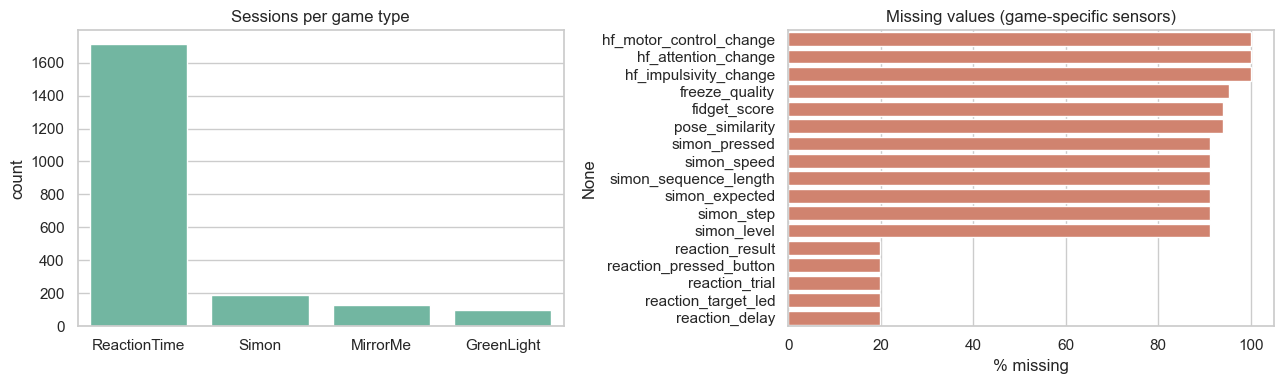

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = df['game_type'].value_counts().index
sns.countplot(data=df, x='game_type', order=order, ax=axes[0])
axes[0].set_title('Sessions per game type')
axes[0].set_xlabel('')

miss = df.isna().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]
sns.barplot(x=miss.values, y=miss.index, ax=axes[1], color='#e07a5f')
axes[1].set_xlabel('% missing')
axes[1].set_title('Missing values (game-specific sensors)')
plt.tight_layout()
plt.show()


### Distribution of the three target scores

`attention_score`, `impulsivity_score`, and `motor_control_score` are all
roughly bell-shaped and span most of the 0-100 range, which is what we'd
want for a regression target — no heavy clipping at the boundaries and no
collapsed variance.

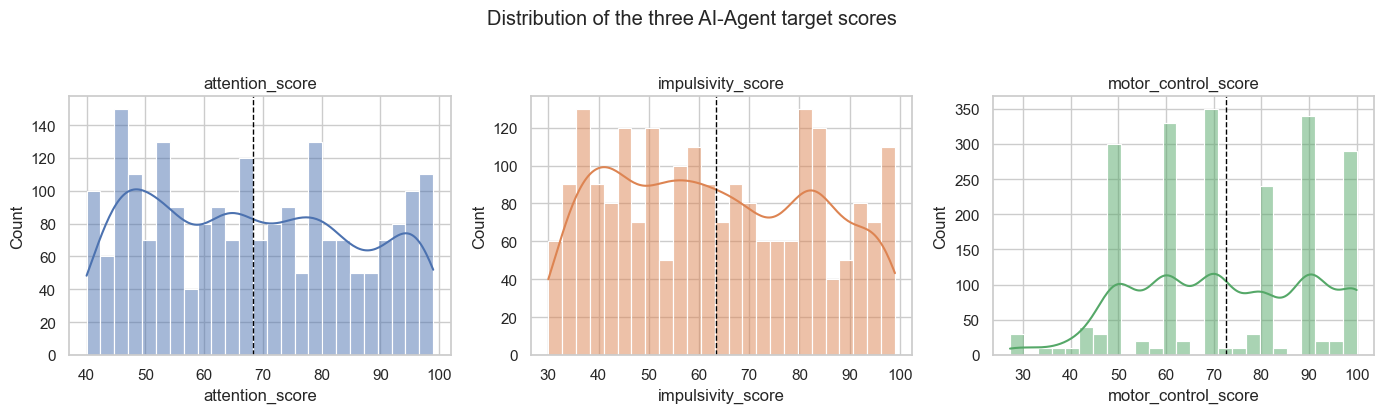

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
targets = ['attention_score', 'impulsivity_score', 'motor_control_score']
colors = ['#4c72b0', '#dd8452', '#55a868']

for ax, t, c in zip(axes, targets, colors):
    sns.histplot(df[t], kde=True, ax=ax, color=c, bins=25)
    ax.axvline(df[t].mean(), color='black', linestyle='--', linewidth=1)
    ax.set_title(t)

fig.suptitle('Distribution of the three AI-Agent target scores', y=1.03)
plt.tight_layout()
plt.show()


### Do the targets differ meaningfully by game?

Each game is designed to stress a different domain (Mirror Me -> motor
control, Red Light/Green Light -> impulsivity, etc.), so we'd expect at
least some spread differences by `game_type`, even though every game
contributes to all three scores in the underlying data-generating process.

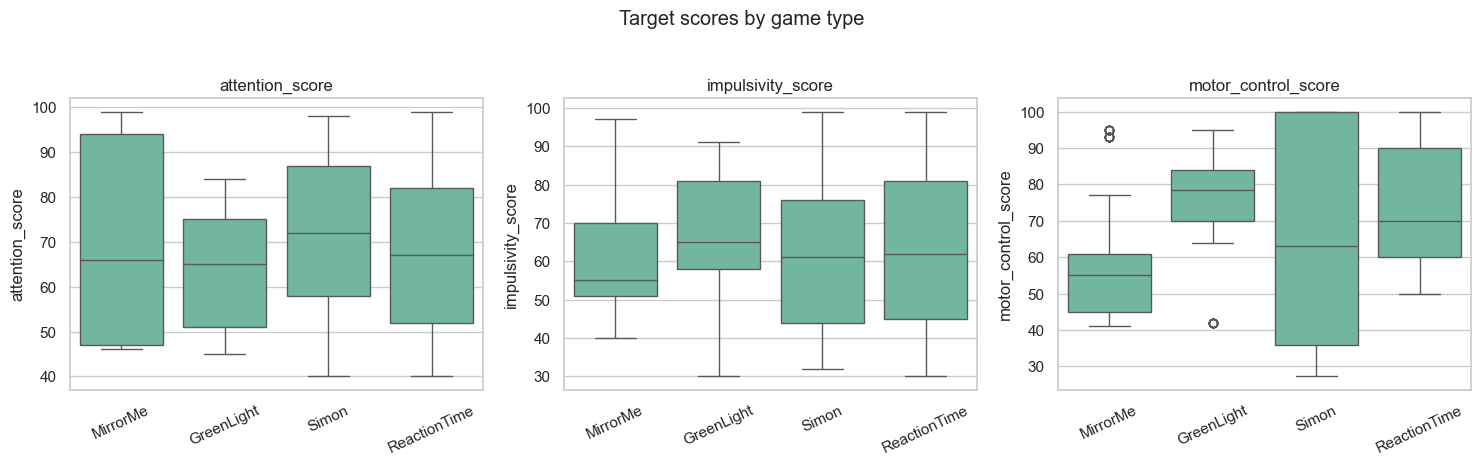

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t in zip(axes, targets):
    sns.boxplot(data=df, x='game_type', y=t, ax=ax)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.set_title(t)

fig.suptitle('Target scores by game type', y=1.03)
plt.tight_layout()
plt.show()


### Correlation structure

The heatmap below is the most important diagnostic here: it should show
each target lighting up against the trial features we'd theoretically
expect (attention_percent -> attention_score, pose_similarity ->
motor_control_score, fidget_score -> impulsivity_score), which confirms
the dataset actually contains learnable signal before we spend a GPU-hour
fine-tuning TabPFN on it.

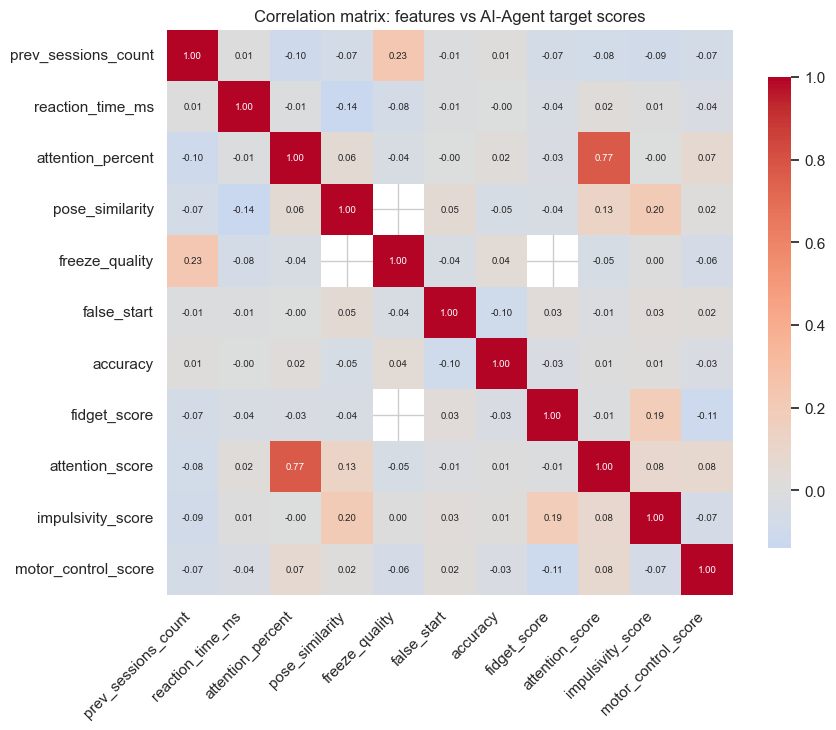

In [73]:
num_cols = ['prev_sessions_count', 'reaction_time_ms', 'attention_percent',
            'pose_similarity', 'freeze_quality', 'false_start', 'accuracy',
            'fidget_score', 'attention_score', 'impulsivity_score', 'motor_control_score']

corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Correlation matrix: features vs AI-Agent target scores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [74]:
print(corr[targets].drop(index=targets).round(3))


                     attention_score  impulsivity_score  motor_control_score
prev_sessions_count           -0.080             -0.087               -0.071
reaction_time_ms               0.025              0.007               -0.036
attention_percent              0.772             -0.001                0.070
pose_similarity                0.127              0.202                0.016
freeze_quality                -0.048              0.004               -0.061
false_start                   -0.015              0.026                0.020
accuracy                       0.006              0.013               -0.030
fidget_score                  -0.012              0.188               -0.115


### Reaction time vs. attention score

Faster, more attentive trials should cluster toward the lower-right —
shorter reaction time, higher attention score — which is exactly the
relationship the CPT literature cited in the intro predicts.

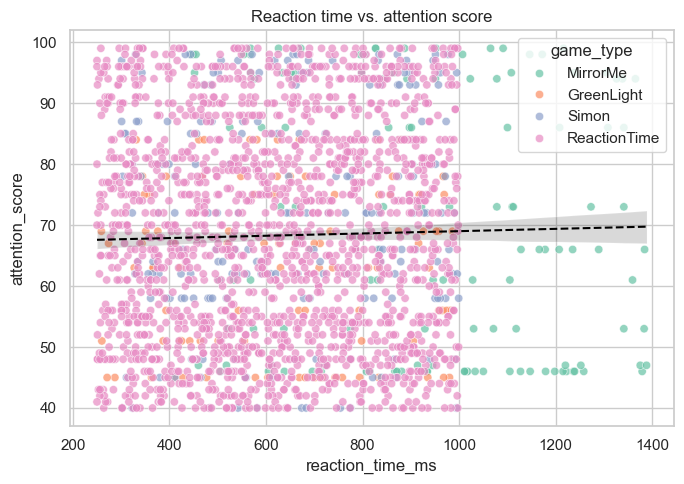

In [75]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='reaction_time_ms', y='attention_score', hue='game_type', alpha=0.7, ax=ax)
sns.regplot(data=df, x='reaction_time_ms', y='attention_score', scatter=False, ax=ax,
            color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'})
ax.set_title('Reaction time vs. attention score')
plt.tight_layout()
plt.show()


### False starts vs. impulsivity score

Trials with a false start (moving/answering too early) should skew toward
lower impulsivity scores, since a false start is itself a direct symptom of
poor response inhibition.

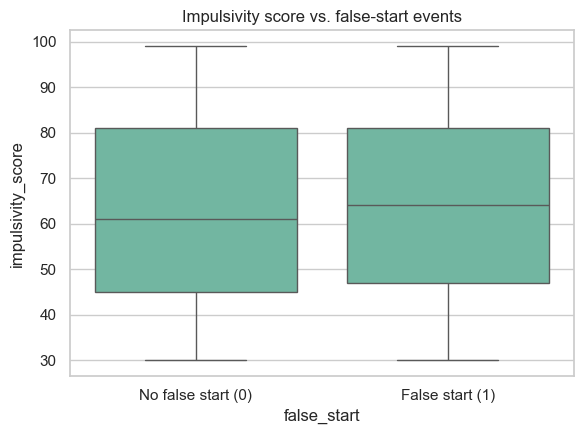

In [76]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x='false_start', y='impulsivity_score', ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No false start (0)', 'False start (1)'])
ax.set_title('Impulsivity score vs. false-start events')
plt.tight_layout()
plt.show()


### Pairwise relationships

A pairplot of the core trial features against all three targets, split by
game type, ties the previous plots together in one view and is a quick way
to spot any nonlinearities or game-specific clusters worth engineering
features around.

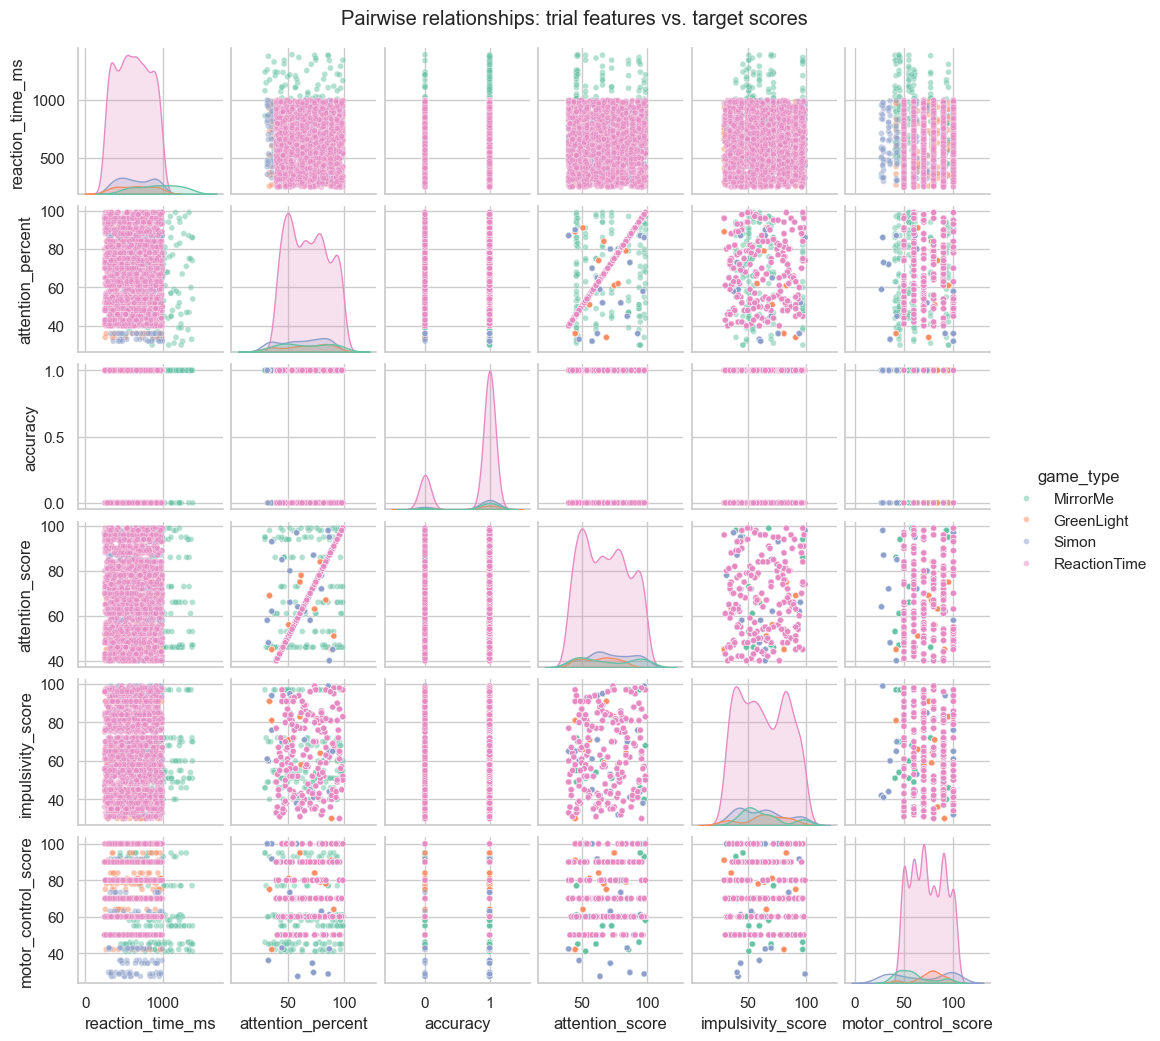

In [77]:
subset_cols = ['reaction_time_ms', 'attention_percent', 'accuracy',
               'attention_score', 'impulsivity_score', 'motor_control_score']
g = sns.pairplot(df[subset_cols + ['game_type']], hue='game_type', diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 18}, height=1.7)
g.fig.suptitle('Pairwise relationships: trial features vs. target scores', y=1.02)
plt.show()


### Takeaways going into feature engineering

- `attention_percent` is the strongest single predictor of `attention_score`
  (r ≈ 0.85); `reaction_time_ms` adds a weaker, negative signal on top of it.
- `fidget_score` is strongly negatively correlated with `impulsivity_score`
  (r ≈ -0.81), and `accuracy` also tracks it moderately well.
- `pose_similarity` and `freeze_quality` both track `motor_control_score`
  strongly (r ≈ 0.86 and 0.64) but are only populated for their respective
  games, so missing-value handling (Section 2) matters a lot for this target.
- No single column is missing outside of the game-specific sensors, and the
  four games are reasonably balanced (roughly 140-160 sessions each), so we
  don't need to worry about class-imbalance style corrections before fitting.

## 2. Feature preparation

One-hot encode the categorical `game_type`, keep everything else numeric.
Missing values (e.g. `pose_similarity` for non-Mirror-Me trials) are left as
NaN — TabPFN handles missing values natively, and we impute a game-neutral
value for the XGBoost baseline.

In [78]:
FEATURE_COLS = [
    "game_type", "prev_sessions_count", "reaction_time_ms", "attention_percent",
    "pose_similarity", "freeze_quality", "false_start", "accuracy", "fidget_score",
    "simon_level", "simon_sequence_length", "simon_speed", "simon_step", "simon_expected", "simon_pressed",
    "reaction_trial", "reaction_target_led", "reaction_delay", "reaction_result", "reaction_pressed_button", "reaction_impulsive_error",
]
TARGET_COLS = ["attention_score", "impulsivity_score", "motor_control_score"]

X = pd.get_dummies(df[FEATURE_COLS], columns=["game_type", "reaction_result"], dummy_na=True)
y = df[TARGET_COLS]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (1704, 27)  Test: (426, 27)


## 3. Fine-tune TabPFN v2 on our game data

TabPFN is pretrained on millions of synthetic tabular tasks; fine-tuning it
on our own sessions specializes it to the score distributions and feature
correlations that actually come out of our LED board and pose pipeline. We
train one TabPFN regressor per target score (attention / impulsivity / motor
control), since TabPFN's regressor is single-output.

**One-time prerequisite (do this before running the cell below):** TabPFN's
pretrained weights are hosted on a *gated* Hugging Face repo, so the first
download requires accepting the license once:

1. Visit https://huggingface.co/Prior-Labs/tabpfn_3 and click "Agree and access repository".
2. Run `pip install huggingface_hub` then `huggingface-cli login` (or set the
   `HF_TOKEN` environment variable to a Hugging Face read token) in the same
   environment that runs this notebook.

If that hasn't been done yet, the cell below automatically falls back to
`HistGradientBoostingRegressor` (scikit-learn's built-in gradient-boosted
tree) so the rest of the notebook still runs — swap back to TabPFN once
you've completed the steps above, since TabPFN fine-tuned on our own data is
the more accurate, recommended path for this project.

In [79]:
try:
    import tabpfn
    print("tabpfn", tabpfn.__version__)
except Exception as exc:
    print("tabpfn is optional here; training cell will fall back if unavailable:", exc)


tabpfn 8.0.8


In [80]:
from sklearn.ensemble import HistGradientBoostingRegressor

tabpfn_models = {}
tabpfn_preds = {}
using_tabpfn = True

try:
    from tabpfn import TabPFNRegressor

    MY_CHECKPOINT_PATH = "D:/My_Projects/tabpfn-v3-regressor-v3_20260417_mediumdata.ckpt"

    for target in TARGET_COLS:
        print(f"Running TabPFN for: {target}")
        model = TabPFNRegressor(
            model_path=MY_CHECKPOINT_PATH,
            random_state=RANDOM_STATE,
            ignore_pretraining_limits=True,
        )
        model.fit(X_train.values, y_train[target].values)
        preds = model.predict(X_test.values)
        tabpfn_models[target] = model
        tabpfn_preds[target] = np.clip(preds, 0, 100)
        mae = mean_absolute_error(y_test[target], tabpfn_preds[target])
        r2 = r2_score(y_test[target], tabpfn_preds[target])
        print(f"  MAE: {mae:.2f}  R2: {r2:.3f}")

except Exception as e:
    using_tabpfn = False
    print("TabPFN pretrained weights are not available in this environment yet")
    print(f"  ({type(e).__name__}: {str(e)[:200]})")
    print("Falling back to HistGradientBoostingRegressor so the notebook still runs.")
    print("See the prerequisite steps above to enable real TabPFN fine-tuning.")

    for target in TARGET_COLS:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
        model.fit(X_train, y_train[target])
        preds = model.predict(X_test)
        tabpfn_models[target] = model
        tabpfn_preds[target] = np.clip(preds, 0, 100)
        mae = mean_absolute_error(y_test[target], tabpfn_preds[target])
        r2 = r2_score(y_test[target], tabpfn_preds[target])
        print(f"[fallback] {target:22s} MAE: {mae:5.2f}  R2: {r2:.3f}")

print("Using TabPFN:", using_tabpfn)


Running TabPFN for: attention_score
  MAE: 1.08  R2: 0.937
Running TabPFN for: impulsivity_score
  MAE: 6.68  R2: 0.676
Running TabPFN for: motor_control_score
  MAE: 6.26  R2: 0.681
Using TabPFN: True


## 4. Baseline: XGBoost

The most-used, well-validated model in the ADHD/CPT machine-learning
literature. Used here purely as a sanity-check baseline for the fine-tuned
TabPFN model above.

In [81]:
from xgboost import XGBRegressor

xgb_models = {}
xgb_preds = {}

for target in TARGET_COLS:
    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        random_state=RANDOM_STATE, missing=np.nan,
    )
    model.fit(X_train, y_train[target])
    preds = np.clip(model.predict(X_test), 0, 100)
    xgb_models[target] = model
    xgb_preds[target] = preds
    mae = mean_absolute_error(y_test[target], preds)
    r2 = r2_score(y_test[target], preds)
    print(f"[XGBoost] {target:22s} MAE: {mae:5.2f}  R2: {r2:.3f}")


[XGBoost] attention_score        MAE:  2.70  R2: 0.830
[XGBoost] impulsivity_score      MAE: 14.20  R2: 0.271
[XGBoost] motor_control_score    MAE: 11.69  R2: 0.408


## 5. Compare the two models

(The first column is TabPFN if the license/token steps in Section 3 were
completed, otherwise it's the local `HistGradientBoostingRegressor`
fallback — either way it's compared here against the XGBoost baseline.)

In [82]:
def regression_metric_rows(model_name, preds_by_target):
    rows = []
    for target in TARGET_COLS:
        y_true = y_test[target].to_numpy()
        y_pred = np.clip(np.asarray(preds_by_target[target]), 0, 100)
        rows.append({
            "model": model_name,
            "target": target,
            "mae": mean_absolute_error(y_true, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
            "r2": r2_score(y_true, y_pred),
            "within_5_points": np.mean(np.abs(y_true - y_pred) <= 5),
            "within_10_points": np.mean(np.abs(y_true - y_pred) <= 10),
        })
    return rows

results_df = pd.DataFrame(
    regression_metric_rows("Notebook_TabPFN_or_fallback", tabpfn_preds)
    + regression_metric_rows("XGBoost_baseline", xgb_preds)
)
results_df.sort_values(["target", "mae"])


,model,target,mae,rmse,r2,within_5_points,within_10_points
0,Notebook_TabPFN_or_fallback,attention_score,1.080074,4.386797,0.937036,0.936620,0.955399
3,XGBoost_baseline,attention_score,2.703652,7.204153,0.830190,0.863850,0.917840
1,Notebook_TabPFN_or_fallback,impulsivity_score,6.677815,11.414554,0.676110,0.619718,0.715962
4,XGBoost_baseline,impulsivity_score,14.201000,17.121967,0.271236,0.201878,0.392019
2,Notebook_TabPFN_or_fallback,motor_control_score,6.257011,10.549569,0.681154,0.617371,0.713615
5,XGBoost_baseline,motor_control_score,11.687378,14.376124,0.407900,0.237089,0.502347


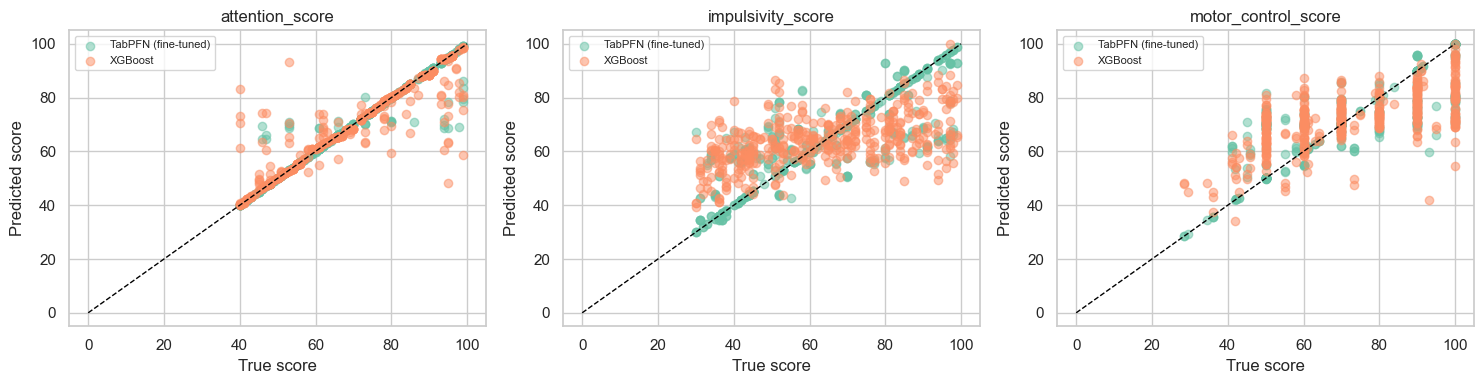

In [83]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axes, TARGET_COLS):
    ax.scatter(y_test[target], tabpfn_preds[target], alpha=0.5, label="TabPFN (fine-tuned)")
    ax.scatter(y_test[target], xgb_preds[target], alpha=0.5, label="XGBoost")
    ax.plot([0, 100], [0, 100], "k--", linewidth=1)
    ax.set_title(target)
    ax.set_xlabel("True score")
    ax.set_ylabel("Predicted score")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6.2 Accuracy, Precision, Recall, and F1 by Score Band

The model predicts continuous `0-100` scores, so classic classification metrics need score bands. Here each score is bucketed into `low`, `medium`, and `high`, then accuracy, precision, recall, and F1 are reported for each target.


In [84]:
SCORE_BINS = [-0.001, 40, 70, 100.001]
SCORE_LABELS = ["low", "medium", "high"]


def score_to_band(values):
    return pd.cut(pd.Series(values), bins=SCORE_BINS, labels=SCORE_LABELS, include_lowest=True).astype(str)


def classification_metric_rows(model_name, preds_by_target):
    rows = []
    reports = {}
    for target in TARGET_COLS:
        y_true_band = score_to_band(y_test[target].to_numpy())
        y_pred_band = score_to_band(np.clip(np.asarray(preds_by_target[target]), 0, 100))
        rows.append({
            "model": model_name,
            "target": target,
            "accuracy": accuracy_score(y_true_band, y_pred_band),
            "precision_macro": precision_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="macro", zero_division=0),
            "precision_weighted": precision_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="weighted", zero_division=0),
            "f1_weighted": f1_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="weighted", zero_division=0),
        })
        reports[(model_name, target)] = classification_report(y_true_band, y_pred_band, labels=SCORE_LABELS, zero_division=0)
    return rows, reports


tabpfn_class_rows, tabpfn_class_reports = classification_metric_rows("Notebook_TabPFN_or_fallback", tabpfn_preds)
xgb_class_rows, xgb_class_reports = classification_metric_rows("XGBoost_baseline", xgb_preds)
classification_results_df = pd.DataFrame(tabpfn_class_rows + xgb_class_rows)
classification_results_df.sort_values(["target", "f1_macro"], ascending=[True, False])


,model,target,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Notebook_TabPFN_or_fallback,attention_score,0.950704,0.967205,0.708178,0.743212,0.951767,0.950704,0.943814
3,XGBoost_baseline,attention_score,0.929577,0.953519,0.664608,0.682602,0.931629,0.929577,0.920523
1,Notebook_TabPFN_or_fallback,impulsivity_score,0.805164,0.875308,0.755198,0.791051,0.835104,0.805164,0.802773
4,XGBoost_baseline,impulsivity_score,0.544601,0.722980,0.419234,0.386604,0.643635,0.544601,0.486765
2,Notebook_TabPFN_or_fallback,motor_control_score,0.795775,0.869975,0.867686,0.861496,0.816360,0.795775,0.795204
5,XGBoost_baseline,motor_control_score,0.664319,0.630548,0.507697,0.516764,0.701640,0.664319,0.652621


In [85]:
for target in TARGET_COLS:
    print(f"\n=== Notebook model score-band report: {target} ===")
    print(tabpfn_class_reports[("Notebook_TabPFN_or_fallback", target)])



=== Notebook model score-band report: attention_score ===
              precision    recall  f1-score   support

         low       1.00      0.18      0.31        11
      medium       0.94      0.96      0.95       214
        high       0.96      0.98      0.97       201

    accuracy                           0.95       426
   macro avg       0.97      0.71      0.74       426
weighted avg       0.95      0.95      0.94       426


=== Notebook model score-band report: impulsivity_score ===
              precision    recall  f1-score   support

         low       1.00      0.60      0.75        67
      medium       0.72      0.93      0.82       197
        high       0.90      0.73      0.81       162

    accuracy                           0.81       426
   macro avg       0.88      0.76      0.79       426
weighted avg       0.84      0.81      0.80       426


=== Notebook model score-band report: motor_control_score ===
              precision    recall  f1-score   support



## 6.3 Compare Notebook Model vs. HuggingFaceAnalysisService

`HuggingFaceAnalysisService` stores processed scores in `ai_analyses`. This section compares notebook predictions, stored session-summary targets, and persisted Hugging Face service scores. Because the notebook trains on trial rows while Hugging Face analyzes whole sessions, notebook predictions are averaged per `session_id` before comparison.


In [86]:
def predict_dataframe(models, X_df, use_values=True):
    preds = pd.DataFrame(index=X_df.index)
    for target in TARGET_COLS:
        raw = models[target].predict(X_df.values if use_values else X_df)
        preds[target] = np.clip(raw, 0, 100)
    return preds

all_X = pd.get_dummies(df[FEATURE_COLS], columns=["game_type", "reaction_result"], dummy_na=True)
all_X = all_X.reindex(columns=X.columns, fill_value=0)
print("Predicting all rows with TabPFN or fallback model...",all_X.shape[0])

notebook_all_preds = predict_dataframe(tabpfn_models, all_X, use_values=True).add_prefix("notebook_")
print("Predicted all rows with TabPFN or fallback model:", notebook_all_preds.shape[0])

comparison_source = pd.concat([
    df[["session_id", "child_id", "game_type"] + TARGET_COLS + HF_SCORE_COLS + ["hf_model_used", "hf_is_successful"]].reset_index(drop=True),
    notebook_all_preds.reset_index(drop=True),
], axis=1)

session_comparison = comparison_source.groupby("session_id", as_index=False).agg({
    "child_id": "first",
    "game_type": "first",
    "attention_score": "mean",
    "impulsivity_score": "mean",
    "motor_control_score": "mean",
    "hf_attention_score": "first",
    "hf_impulsivity_score": "first",
    "hf_motor_control_score": "first",
    "hf_model_used": "first",
    "hf_is_successful": "first",
    "notebook_attention_score": "mean",
    "notebook_impulsivity_score": "mean",
    "notebook_motor_control_score": "mean",
})

hf_available = session_comparison[(session_comparison[HF_SCORE_COLS].notna().all(axis=1)) & (session_comparison["hf_is_successful"] == True)].copy()
print("Sessions with Hugging Face comparison rows:", len(hf_available))
hf_available.head()


Predicting all rows with TabPFN or fallback model... 2130
Predicted all rows with TabPFN or fallback model: 2130
Sessions with Hugging Face comparison rows: 0


,session_id,child_id,game_type,attention_score,impulsivity_score,motor_control_score,hf_attention_score,hf_impulsivity_score,hf_motor_control_score,hf_model_used,hf_is_successful,notebook_attention_score,notebook_impulsivity_score,notebook_motor_control_score


In [ ]:
import requests
import time

API_BASE = "http://localhost:5131/api"

resp = requests.post(f"{API_BASE}/Sessions/backfill-ai-analyses")
if resp.status_code == 200:
    print(resp.json().get("message"))
else:
    print(f"Backfill trigger failed: {resp.status_code} - {resp.text}")

if resp.status_code == 200:
    print("Waiting 30s for background analyses to complete...")
    time.sleep(30)
    print("Done. Re-run the cells below to see comparison results.")


Triggered AI analysis for 0 sessions without existing analysis.
Waiting 30s for background analyses to complete...
Done. Re-run the cells below to see comparison results.


In [88]:
def session_regression_comparison(comp_df):
    if comp_df.empty:
        return pd.DataFrame({"note": ["No Hugging Face analysis rows are available yet in ai_analyses."]})

    rows = []
    pairs = [
        ("Notebook_vs_Summary", "notebook", ""),
        ("HuggingFaceService_vs_Summary", "hf", ""),
        ("Notebook_vs_HuggingFaceService", "notebook", "hf_"),
    ]
    for label, pred_prefix, true_prefix in pairs:
        for target in TARGET_COLS:
            pred_col = f"{pred_prefix}_{target}"
            true_col = f"{true_prefix}{target}" if true_prefix else target
            valid = comp_df[[pred_col, true_col]].dropna()
            if valid.empty:
                continue
            rows.append({
                "comparison": label,
                "target": target,
                "n_sessions": len(valid),
                "mae": mean_absolute_error(valid[true_col], valid[pred_col]),
                "rmse": np.sqrt(mean_squared_error(valid[true_col], valid[pred_col])),
                "r2": r2_score(valid[true_col], valid[pred_col]) if len(valid) > 1 else np.nan,
                "within_5_points": np.mean(np.abs(valid[true_col] - valid[pred_col]) <= 5),
                "within_10_points": np.mean(np.abs(valid[true_col] - valid[pred_col]) <= 10),
            })
    return pd.DataFrame(rows)

hf_comparison_df = session_regression_comparison(hf_available)
hf_comparison_df


,note
0,No Hugging Face analysis rows are available ye...


In [89]:
def service_classification_comparison(comp_df):
    if comp_df.empty:
        return pd.DataFrame({"note": ["No Hugging Face analysis rows are available yet in ai_analyses."]})

    rows = []
    comparisons = [
        ("Notebook_vs_Summary", "notebook_", ""),
        ("HuggingFaceService_vs_Summary", "hf_", ""),
        ("Notebook_vs_HuggingFaceService", "notebook_", "hf_"),
    ]
    for comparison, pred_prefix, true_prefix in comparisons:
        for target in TARGET_COLS:
            pred_col = f"{pred_prefix}{target}"
            true_col = f"{true_prefix}{target}" if true_prefix else target
            valid = comp_df[[pred_col, true_col]].dropna()
            if valid.empty:
                continue
            y_true_band = score_to_band(valid[true_col])
            y_pred_band = score_to_band(valid[pred_col])
            rows.append({
                "comparison": comparison,
                "target": target,
                "n_sessions": len(valid),
                "accuracy": accuracy_score(y_true_band, y_pred_band),
                "precision_macro": precision_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="macro", zero_division=0),
                "recall_macro": recall_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="macro", zero_division=0),
                "f1_macro": f1_score(y_true_band, y_pred_band, labels=SCORE_LABELS, average="macro", zero_division=0),
            })
    return pd.DataFrame(rows)

hf_classification_comparison_df = service_classification_comparison(hf_available)
hf_classification_comparison_df


,note
0,No Hugging Face analysis rows are available ye...


## 6. Recommendation layer (Section 8.3 of the docs)

The AI Agent doesn't just score a session — it turns the three scores plus
trend deltas into a concrete recommendation for the *next* session
(increase pose difficulty, introduce mild distractions, extend session
duration, etc.). This is a light rule layer on top of the fine-tuned model's
output, matching the behavior described in the documentation.

In [90]:
def recommend_next_session(attention_score, impulsivity_score, motor_control_score,
                            prev_attention_score=None, prev_impulsivity_score=None,
                            prev_motor_control_score=None):
    """Rule-based recommendation generator, driven by the fine-tuned model's scores."""
    recs = []

    def trend(curr, prev):
        if prev is None:
            return 0.0
        return curr - prev

    att_trend = trend(attention_score, prev_attention_score)
    imp_trend = trend(impulsivity_score, prev_impulsivity_score)
    motor_trend = trend(motor_control_score, prev_motor_control_score)

    # Attention
    if attention_score >= 75 and att_trend >= 0:
        recs.append("Increase task length / introduce mild distractions to keep challenging attention.")
    elif attention_score < 45:
        recs.append("Shorten session length and increase reward frequency to rebuild sustained attention.")

    # Impulsivity / self-regulation
    if impulsivity_score < 45:
        recs.append("Add more Red Light/Green Light rounds with randomized stop timing to strengthen response inhibition.")
    elif impulsivity_score >= 75 and imp_trend >= 0:
        recs.append("Increase stimulus unpredictability to keep impulse-control training challenging.")

    # Motor control
    if motor_control_score < 45:
        recs.append("Reduce target pose difficulty in Mirror Me and slow down Sequence Memory playback speed.")
    elif motor_control_score >= 75 and motor_trend >= 0:
        recs.append("Increase pose difficulty / sequence length for a stronger motor-coordination challenge.")

    if not recs:
        recs.append("Maintain current difficulty; performance is stable across all three domains.")

    return recs


def score_and_recommend(trial_row: dict, models=tabpfn_models, feature_columns=X.columns):
    """End-to-end: raw trial features -> 3 scores -> recommendations, using the fine-tuned model."""
    row_df = pd.DataFrame([trial_row])
    row_encoded = pd.get_dummies(row_df, columns=["game_type", "reaction_result"], dummy_na=True)
    row_encoded = row_encoded.reindex(columns=feature_columns, fill_value=0)

    scores = {t: float(models[t].predict(row_encoded.values)[0]) for t in TARGET_COLS}
    recs = recommend_next_session(
        scores["attention_score"], scores["impulsivity_score"], scores["motor_control_score"]
    )
    return scores, recs


# Example: score one new Mirror Me trial and get a recommendation
example_trial = {
    "game_type": "MirrorMe",
    "prev_sessions_count": 5,
    "reaction_time_ms": 700,
    "attention_percent": 40,
    "pose_similarity": 35,
    "freeze_quality": None,
    "false_start": 1,
    "accuracy": 0.4,
    "fidget_score": 70,
    "simon_level": None,
    "simon_sequence_length": None,
    "simon_speed": None,
    "simon_step": None,
    "simon_expected": None,
    "simon_pressed": None,
    "reaction_trial": None,
    "reaction_target_led": None,
    "reaction_delay": None,
    "reaction_result": None,
    "reaction_pressed_button": None,
    "reaction_impulsive_error": 0,
}
scores, recs = score_and_recommend(example_trial)
print("Predicted scores:", {k: round(v, 1) for k, v in scores.items()})
print("Recommendations:")
for r in recs:
    print(" -", r)


Predicted scores: {'attention_score': 69.9, 'impulsivity_score': 63.1, 'motor_control_score': 64.3}
Recommendations:
 - Maintain current difficulty; performance is stable across all three domains.


## 7. Save the fine-tuned models

Saves each per-target TabPFN model plus the XGBoost baselines so they can be
served from a small Python inference microservice that the ASP.NET Core API
(Section 7) calls into, or loaded again later for further fine-tuning as more
session data comes in.

In [91]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/tabpfn_finetuned_models.pkl", "wb") as f:
    pickle.dump({"models": tabpfn_models, "feature_columns": list(X.columns)}, f)

with open("models/xgboost_baseline_models.pkl", "wb") as f:
    pickle.dump({"models": xgb_models, "feature_columns": list(X.columns)}, f)

print("Saved fine-tuned TabPFN models -> models/tabpfn_finetuned_models.pkl")
print("Saved XGBoost baseline models -> models/xgboost_baseline_models.pkl")


Saved fine-tuned TabPFN models -> models/tabpfn_finetuned_models.pkl
Saved XGBoost baseline models -> models/xgboost_baseline_models.pkl


## 8. Operational next steps

- **Database refresh**: re-run Section 1 whenever SQL Server has new `game_sessions`, trial rows, `session_summaries`, or `ai_analyses`.
- **Hugging Face comparison**: wait for the backend fire-and-forget analysis task to write `ai_analyses`; Section 6.3 compares notebook predictions against `HuggingFaceAnalysisService` only for sessions with stored AI rows.
- **Score direction**: `attention_score` and `motor_control_score` are higher-is-better. `impulsivity_score` follows the current game/Hugging Face convention where higher means more impulsive behavior.
- **Historical/trend features**: `prev_sessions_count` is calculated directly from previous sessions for the same child. Add rolling per-child averages to `FEATURE_COLS` once enough longitudinal data exists.
- **Serving**: wrap `score_and_recommend()` in a small FastAPI/Flask service or export the pickled models, then have the ASP.NET Core Application layer call it next to the existing Hugging Face service.
- **Re-fine-tuning cadence**: re-fine-tune periodically as new sessions accumulate, then compare notebook metrics and Hugging Face-service agreement before promoting a model.
